# Intel Image Classification using PyTorch

This project implements a custom Convolutional Neural Network (CNN) using PyTorch
to classify images into six categories: buildings, forest, glacier, mountain, sea,
and street.

The project covers the complete computer vision pipeline from dataset loading and
preprocessing to model training, evaluatione.

## 1. Dataset acquisition

In [1]:
! pip install opendatasets --quiet
import opendatasets as od

In [2]:
od.download('https://www.kaggle.com/datasets/puneet6060/intel-image-classification')

Skipping, found downloaded files in "./intel-image-classification" (use force=True to force download)


## 2. Setup

In [3]:
import torch
import torchvision
import torch.nn as nn
import torchvision.datasets
import torchvision.transforms as transforms
import torch.optim as optim
from torch.utils.data import DataLoader

In [4]:
device = 'cuda' if torch.cuda.is_available else 'cpu'
device

'cuda'

## 3. Preprocessing

In [5]:
train_transforms = transforms.Compose({
    transforms.Resize((64,64)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
})
test_transforms = transforms.Compose({
    transforms.Resize((64,64)),
    transforms.ToTensor()
})

## 4. Dataset

In [6]:
training_dataset = torchvision.datasets.ImageFolder('/content/intel-image-classification/seg_train/seg_train',transform=train_transforms)

In [7]:
testing_dataset = torchvision.datasets.ImageFolder('/content/intel-image-classification/seg_test/seg_test',transform=test_transforms)

## 5. DataLoaders

In [8]:
train_loader = DataLoader(training_dataset,batch_size = 32, shuffle = True, num_workers = 2, pin_memory = True)
test_loader = DataLoader(testing_dataset,batch_size = 32, shuffle = True, num_workers = 2, pin_memory = True)

## 6. CNN Model

In [9]:
class CNN(nn.Module):
	def __init__(self,labels):
		super().__init__()
		self.Architecture_one = nn.Sequential(
			nn.Conv2d(3, 16, kernel_size=  3, stride = 1),
			nn.ReLU(), nn.MaxPool2d(2),
			nn.Conv2d(16, 32, kernel_size= 3, stride = 1),
			nn.ReLU(), nn.MaxPool2d(2),
      nn.Conv2d(32, 64, kernel_size=  3, stride = 1),
			nn.ReLU(), nn.MaxPool2d(2),
			nn.Flatten()
			)
		self.Architecture_two = nn.Sequential(
			nn.Linear(2304,128),
			nn.ReLU(),
			nn.Linear(128, labels),
			)
	def forward(self,x):
		x = self.Architecture_one(x)
		x = self.Architecture_two(x)
		return x

In [10]:
# Getting the number of classes/label
named_classes = training_dataset.classes
label = len(training_dataset.classes)
model = CNN(label).to(device)
named_classes

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

In [11]:
criterion = nn.CrossEntropyLoss()
optimiser = optim.Adam(model.parameters(),lr = 0.002)

## 7. Training

In [12]:
train_losses = []
train_accuracies = []

test_losses = []
test_accuracies = []

In [13]:
def train():
    epochs = 10
    for epoch in range(epochs):


        model.train()

        train_loss = 0
        train_correct = 0
        train_samples = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            output = model(images)
            loss = criterion(output, labels)
            optimiser.zero_grad()
            loss.backward()
            optimiser.step()
            train_loss += loss.item() * images.size(0)
            train_losses.append(train_loss)
            predictions = output.argmax(dim=1)
            train_correct += (predictions == labels).sum().item()
            train_accuracies.append(train_correct)
            train_samples += labels.size(0)


        train_loss = train_loss / train_samples
        train_accuracy = train_correct / train_samples



        model.eval()

        test_loss = 0
        test_correct = 0
        test_samples = 0

        with torch.inference_mode():

            for images, labels in test_loader:
                images = images.to(device)
                labels = labels.to(device)

                output = model(images)
                loss = criterion(output, labels)
                test_loss += loss.item() * images.size(0)
                test_losses.append(test_loss)
                predictions = output.argmax(dim=1)
                test_correct += (predictions == labels).sum().item()
                test_accuracies.append(test_correct)
                test_samples += labels.size(0)

        test_loss = test_loss / test_samples
        test_accuracy = test_correct / test_samples

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Test Loss: {test_loss:.4f} | "
            f"Test Acc: {test_accuracy:.4f}"
        )

In [14]:
train()

Epoch [1/10] Train Loss: 1.0624 | Train Acc: 0.5874 | Test Loss: 0.8875 | Test Acc: 0.6587
Epoch [2/10] Train Loss: 0.8164 | Train Acc: 0.6855 | Test Loss: 0.7915 | Test Acc: 0.6987
Epoch [3/10] Train Loss: 0.7161 | Train Acc: 0.7309 | Test Loss: 0.7906 | Test Acc: 0.7080
Epoch [4/10] Train Loss: 0.6434 | Train Acc: 0.7651 | Test Loss: 0.6411 | Test Acc: 0.7707
Epoch [5/10] Train Loss: 0.5866 | Train Acc: 0.7845 | Test Loss: 0.6089 | Test Acc: 0.7860
Epoch [6/10] Train Loss: 0.5436 | Train Acc: 0.8001 | Test Loss: 0.5846 | Test Acc: 0.7943
Epoch [7/10] Train Loss: 0.5073 | Train Acc: 0.8184 | Test Loss: 0.5874 | Test Acc: 0.7930
Epoch [8/10] Train Loss: 0.4746 | Train Acc: 0.8289 | Test Loss: 0.5509 | Test Acc: 0.8053
Epoch [9/10] Train Loss: 0.4521 | Train Acc: 0.8347 | Test Loss: 0.6219 | Test Acc: 0.7950
Epoch [10/10] Train Loss: 0.4175 | Train Acc: 0.8501 | Test Loss: 0.5656 | Test Acc: 0.8037


## 8. Results

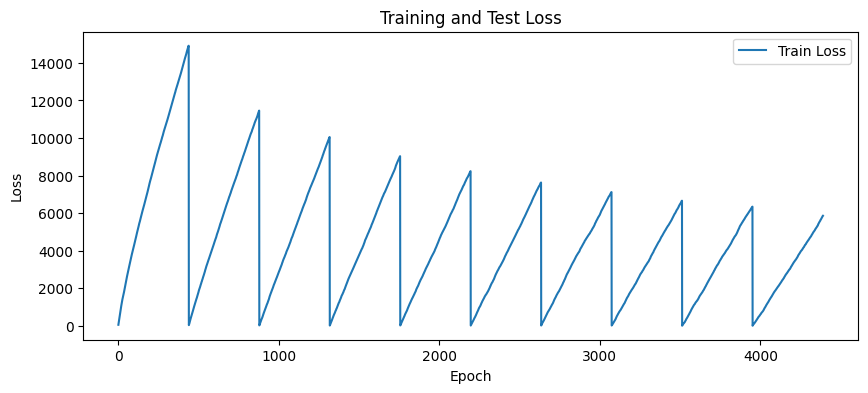

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 4))

plt.plot(epochs, train_losses, label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss")
plt.legend()
plt.show()

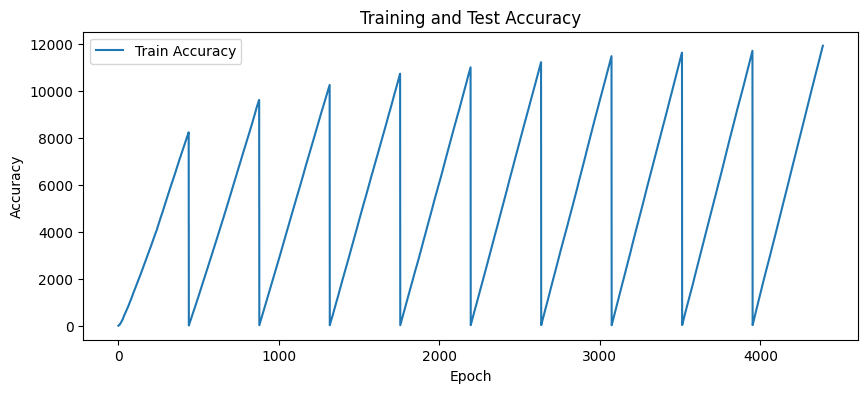

In [ ]:
plt.figure(figsize=(10, 4))

plt.plot(epochs, train_accuracies, label="Train Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Test Accuracy")
plt.legend()
plt.show()

## Conclusion

A custom CNN was trained using PyTorch for multiclass image classification.
The model was evaluated using loss, accuracy.

This project demonstrates the complete PyTorch computer vision workflow,
including dataset handling, CNN construction, batch training, evaluation.